## The Variance of the Saturn V's speed at the end of the atmosphere, by Ayush Gandhi and Mathieu Latendresse

# **Introduction**
---

###Rockets are an innovative technology that have allowed scientists and engineers to reach the moon, like Apollo 11 in 1969, to launch robots on Mars. In both these scientific fields, rockets have allowed us to make fascinating discoveries. They have also paved the way for future space exploration. Therefore, we must understand the functionality of a rocket to fully be able to ensure safe launches and promote scientific discoveries.

###The simulation of rockets under various conditions allows us to understand its complexities in depth, the behaviour of a rocket, and the critical details for a proper launch such as the amount of fuel required. We analyzed the conditions of Saturn V, a rocket that landed on the moon in 1969. Then, we focused our attention on how changing the mass of the fuel impacts the final speed of the rocket at the end of the atmosphere, at 100 km above sea level. All while considering air drag, a unique constant burn rates and unique amounts of fuel in each compartment?

###A critical point to take into account when working with rockets is the amount of fuel stored in each compartment, as it directly impacts the total mass and how long each stage runs for. The Apollo 11 rocket had 3 stages, and each has its own compartment where the fuel was stored. When the fuel in each compartment is depleted, that stage falls off, and the next stage begins using its fuel. As the rocket ascends into every layer of the atmosphere, the varying temperatures at each layer affects the pressure of the air around the rocket. This in turn impacts the air drag experienced by the rocket. Each stage of the rocket has a constant unique burn rate and fuel amount. The net force experienced by the rocket is a combination of the gravitational force, thrust force, and air drag force. As the amount of mass decreases due to the usage of fuel, the total gravitational force decreases over time and the net force increases in the direction of the thrust force until there is no fuel left. When all three stages have used up all their fuel contents, the only forces acting on the rocket will be the gravitational force and the air drag. Within this context, the rocket uses its momentum to coast until its speed is zero.

#**Models and Numerical Methods**

---




###We will be using Euler’s method to calculate the motion of the rocket as it takes into account each change in altitude, acceleration and speed through each iteration of the process. Euler’s method is good for calculating non-periodic motion, such as the trajectory of a rocket. This method will be used in each iteration of a loop, and new value obtained using this method will be appended to a list to properly keep track of each value of acceleration, speed, altitude and position on the x-axis. To calculate the pressure in each layer, the barometric formula will be used. The temperature will be determined with functions for each section of the atmosphere. We will consider a constant fuel burning rate (burning rate is different for each part of the rocket) as well as an unchanging gravitational acceleration through each layer of the atmosphere.

###Then we will be making the program calculate the change in fuel in each iteration using the burn rate for each part of the rocket. Then, we will calculate the linear change in mass for every stage of the rocket as the fuel diminishes. This also affects the net force of gravity as it impacts the mass of the rocket. For the drag coefficient, the rocket will be generalized to the shape of a simple cone. Using this knowledge, the drag force will be calculated. Since the thrust force is constant in each part of the rocket, the net force increases since the mass decreases over time as fuel diminishes. This makes the acceleration of the rocket increase over time.

###At the beginning of each step, the air pressure felt by the rocket will be determined with the current temperature and the altitude using the barometric equations. The new temperature and pressure of the air around the rocket will be calculated with a function at each step. Then we will use this new pressure and temperature to calculate air density, which will tell us the drag force affecting the rocket. Following this, we will calculate the remaining fuel present in the rocket to account for the new mass. This value will tell us the force of gravity. Using these two forces coupled with the thrust force (which is different for each part of the rocket), we will calculate the net force felt by the rocket and then divide this by the total mass (calculated previously) to obtain its current acceleration.

###Using this acceleration, we will calculate the positions and velocities at every step using Euler’s equations of motion. After each iteration, a check will be done to verify if the remaining fuel is above 0. If it isn’t the next segment of the rocket will begin, with different thrust and mass values. If the rocket crosses the 100km mark, the function will create a dictionary item with the final speed associated with a total fuel amount. Then, the calculations for the trajectory will end.

###All of this code will be contained inside a function to be able to initiate the rocket launch with varying fuel values. A numpy array will be created with various fuel amounts that will be run from lowest to highest. Then, from the dictionary containing the final speeds and fuel masses, it will graph all the values together to see how the final speed was affected by the total mass of the fuel.

###The density is calculated in every layer of the atmosphere as the temperature fluctuates in every layer, affecting the air pressure. To do so, certain layers have constant temperature but in other layers, the linear change in temperature is calculated with the following equation:


###$t= t_0-(h-h_0)L\tag{1}$

where:

$t$ is the temperature felt by the rocket in Kelvin ($K$)

$t_0$ is the temperature at the base altitude of the atmosphere layer in Kelvin ($K$)

$h$ is the current altitude in meters ($m$)

$h_0$  is the base altitude of the atmosphere layer in meters($m$)

$L$ is the lapse rate ($\frac{K}{m}$)

###If the temperature is varying in the layer, the air pressure is calculated using the following Barometric equation:

###$P= P_0  (t/t_0)^ \frac{gM}{RL}\tag{2}$


where:

$P$ is the pressure around the rocket (Pa)

$P_0$ is the pressure at the base altitude of the atmosphere layer (Pa)

$t$  is the temperature felt by the rocket in Kelvin ($K$)

$t_0$ is the temperature at the base altitude of the atmosphere layer in Kelvin ($K$)

$g$ is the gravitational acceleration of Earth  ($\frac{m}{s^2}$)

$M$ is the molar mass of the air on Earth ($\frac {kg}{mol}$)

$R$ is the universal gas constant ($\frac{J}{K*mol}$)

$L$ is the lapse rate ($\frac{K}{m}$)

###if the temperature is not varying in the layer, the air pressure is calculated using this equation:

###$P= P_0 e^\frac{-gM(h-h_0)}{RT}\tag{3}$

where:

$P$ is the air pressure around the rocket (Pa)

$P_0$ is the air pressure at the base altitude of the atmosphere layer (Pa)

$g$ is the gravitational acceleration of Earth ($\frac{m}{s^2}$)

$M$ is the molar mass of the air on Earth ($\frac {kg}{mol}$)

$h$ is the current altitude ($m$)

$h_0$  is the base altitude of the atmosphere layer ($m$)

$R$ is the universal gas constant ($\frac{J}{K*mol}$)

$T$ is the temperature in Kelvin ($K$)

###As the rocket ascends through each layer, the given pressures and temperature were used to calculate the air density and then added to a list using the following equation:


###$ρ= \frac {PM}{RT}\tag{4}$

where:

ρ is the density ($\frac{kg}{m^3})$

$P$ is the air pressure around the rocket (Pa)

$M$ is the molar mass of the air on Earth ($\frac {kg}{mol}$)

$R$ is the universal gas constant ($\frac{J}{K*mol}$)

$T$ is the temperature in Kelvin ($K$)

###The drag on the rocket was measured by the following equation using the air density, speed, drag coefficient and the cross-sectional area of the rocket, obtained from official sources:

###$ D = \frac{1}{2} ρv^2C_dA\tag{5}$

where:

ρ is the density ($\frac{kg}{m^3})$

$v$ is the speed of the rocket ($\frac{m}{s}$)

$C_d$ is the drag coefficient of the rocket

$A$ is the cross sectional area of the rocket ($m^2$)


###The gravitational force acting on the rocket is calculated using the following equation:

###$F_g= mg \tag{6}$

where:

$F_g$ is the gravitational force on the rocket ($N$)

$m$ is the total mass of the rocket ($kg$)

$g$ is the gravitational acceleration of the Earth ($\frac{m}{s^2}$)




### Euler's equations to calculate the motion of an object:

###$t_{i+1} =  t_i + \Delta t \tag{7}$
###$x_{i+1} =  x_i + v_{xi}\Delta t \tag{8}$
###$y_{i+1} =  y_i + v_{yi}\Delta t \tag{9}$
###$v_{xi+1} =  v_{xi} + a_{xi}\Delta t \tag{10}$
###$v_{yi+1} =  v_{yi} + a_{yi}\Delta t \tag{11}$

where:

$t_{i+1}$ is the new time step for the current iteration

$t_{i}$ is the old time step from the previous iteration

$x_{i+1}$ is the new x position for the current iteration

$x_{i}$ is the old x position from the previous iteration

$y_{i+1}$ is the new y position for the current iteration

$y_{i}$ is the old y position from the previous iteration

$v_{xi+1}$ is the new horizontal speed for the current iteration

$v_{xi}$ is the old horizontal speed from the previous iteration

$v_{yi+1}$ is the new vertical speed for the current iteration

$v_{yi}$ is the old vertical speed from the previous iteration

$a_{y}$ is the vertical acceleration of the rocket

$a_{x}$ is the horizontal acceleration of the rocket

###In a launch function, the stages of the rocket use fuel as the rocket goes through the atmosphere. As long as the fuel in the current stage is not empty, the fuel depletes by the burn rate of that specific stage. This repeats for each stage until all fuel is used up. The Euler's segment is run to give the current position of the rocket in the atmosphere in every iteration. Acceleration is accounted for by subtracting all forces pulling the rocket downwards from the thrust force, then dividing by the total mass of the rocket for the current iteration.


###When all the fuel of the rocket is depleted, the program enters a coasting phase where the only forces calculated are: air drag and gravitational force. Euler’s equations are also used to keep up with the position of the rocket.

###Finally, the speed of the rocket at 100 km above sea level is graphed with respect to the amount of fuel inside the rocket, where 60 percent of the fuel goes in stage 1, 30 percent in stage 2 and 10 percent in stage 3.

#**Testing & Validation**
---


###In order to test the code, we proceeded in 2 different manners, by first having internal validations and then moving onto external validations.

###For the external validation, we made sure the code was correct by graphing the trajectory of its path and made sure it looks like an appropriate trajectory. We added a constant horizontal speed in order to not have a rocket trajectory graph going upwards and downwards. This constant speed was purely there for visual purposes. It allowed us to make sure the variation in altitudes of the rocket were accurate for each stage of the rocket in its ascent in the atmosphere. In order to make sure this was accurate, it was compared to a rocket trajectory graph found online by a scientist of the U.K's  National Physical Laboratory (NPL).


In [ ]:
#wowowow such cool libraries
import matplotlib.pyplot as plt
import numpy as np

#define constants
g = 9.8
M = 0.0289644

temperature = 20
drag_coeff = 0.5
atmosphere_layer = 0
pressure_layer = 101325
temperature_layer = 288.15
R = 8.314
lapse_layer = 0.0065
altitude_layer = 0
density_layer = 1.225

#define lists that will be used
altitude = []
time = []
a_density = [1.225]

#putting initial values of positions and speed
x = [0]
altitude = [0]

#vx is 10 as to make the trajectory not just go up and down directly
vx =[10]
vy = [0]
ay = [0]

#lists to make it look nicer on the graph
x_cut_off = []
alt_cut_off = []
vy_cut_off = []

#n_iterations = int(t_max/dt)
n_iterations= 200
dt = 1

#calculates density based on your layer and conditions
def calculate_density(altitude):

    if altitude < 11000:
        temp_layer = 288.15
        pressure_layer = 101325
        lapse = 0.0065

        temp = temp_layer - lapse * altitude
        pressure = pressure_layer * (temp / temp_layer) ** (g * M / (R * lapse))

    elif 11000 <= altitude < 20000:
        temp_layer = 216.65
        pressure_layer = 22632.1
        lapse = 0

        temp = temp_layer
        pressure = pressure_layer * np.exp(-g * M * (altitude - 11000) / (R * temp))

    elif 20000 <= altitude < 32000:
        temp_layer = 216.65
        pressure_layer = 5474.89
        lapse = -0.001

        temp = temp_layer - lapse * (altitude - 20000)
        pressure = pressure_layer * (temp / temp_layer) ** (g * M / (R * lapse))

    elif 32000 <= altitude < 47000:
        temp_layer = 228.65
        pressure_layer = 868.02
        lapse = -0.0028

        temp = temp_layer - lapse * (altitude - 32000)
        pressure = pressure_layer * (temp / temp_layer) ** (g * M / (R * lapse))

    elif 47000 <= altitude < 51000:
        temp_layer = 270.65
        pressure_layer = 110.91
        lapse = 0

        temp = temp_layer
        pressure = pressure_layer * np.exp(-g * M * (altitude - 47000) / (R * temp))

    elif 51000 <= altitude < 71000:
        temp_layer = 270.65
        pressure_layer = 66.94
        lapse = 0.0028

        temp = temp_layer - lapse * (altitude - 51000)
        pressure = pressure_layer * (temp / temp_layer) ** (g * M / (R * lapse))

    elif 71000 <= altitude < 84852:
        temp_layer = 214.65
        pressure_layer = 3.96
        lapse = 0.002

        temp = temp_layer - lapse * (altitude - 71000)
        pressure = pressure_layer * (temp / temp_layer) ** (g * M / (R * lapse))

    else: #Above 84.852 km

        temp = 186.87
        pressure = 0.3734

    density = pressure * M / (R * temp)
    a_density.append(density)
    return density


#calculates the force of the air drag felt by the rocket at a given speed, cross sectional aread and air density
def cal_air_drag(speed, cross_sectional_area, air_density):
    air_drag = 0.5 * air_density * speed**2 * drag_coeff * cross_sectional_area
    return air_drag

#determines gravitational force
def gravitational_force(mass):
    return mass*g


#Euler's method to update current position
def Eulers(i):
    x.append(x[i]+vx[i]*dt)
    altitude.append(altitude[i] + vy[i]*dt)
    vx.append(vx[i])
    vy.append(vy[i] + ay[i]*dt)

#launch function, including the three phases of the Saturn V rocket and a coast phase!
def launch(total_fuel):

    #updating information for first stage
    current_fuel1 = total_fuel*0.6
    thrust_force = 33850000
    mass = 189615.218 + current_fuel1
    cross_sectional_area = 317.31

    #initiating the step count to keep track (updated after finishing a loop!)
    time_step = 0

    #------first part of rocket------ cut-offs when fuel is depleted
    while current_fuel1 > 0:

        #Euler's for position
        Eulers(time_step)

        #updating mass and fuel count
        burn_rate = 1285.6
        mass -= burn_rate
        current_fuel1 -= burn_rate

        #calculates density, drag force and grav force to associate them to a variable
        density = calculate_density(altitude[time_step+1])
        drag = cal_air_drag(vy[time_step+1], cross_sectional_area, density)
        grav = gravitational_force(mass)

        #calculates acceleration using F=ma
        negative_forces = drag + grav
        F = thrust_force - negative_forces

        #append new acceleration value
        a_y = F/mass
        ay.append(a_y)


        #keeps track of step count, adding one for the next loop
        time_step += 1

    #adding cut_off points to make visulization better
    x_cut_off.append(x[time_step])
    alt_cut_off.append(altitude[time_step])
    vy_cut_off.append(vy[time_step])

    #updating information for second stage
    current_fuel2 = total_fuel*0.3
    thrust_force = 2431000
    mass = 58980.616 + total_fuel*0.3
    cross_sectional_area = 137.44

    #------second part of rocket------ cut-offs when fuel is depleted
    while current_fuel2 > 0:

        #Euler's for position
        Eulers(time_step)

        #updating mass and fuel count
        burn_rate = 113.53
        mass -= burn_rate
        current_fuel2 -= burn_rate

        #calculates density, drag force and grav force to associate them to a variable
        density = calculate_density(altitude[time_step+1])
        drag = cal_air_drag(vy[time_step+1], cross_sectional_area, density)
        grav = gravitational_force(mass)


        #calculates acceleration using F=ma
        negative_forces = drag + grav
        F = thrust_force - negative_forces


        #append new acceleration value
        a_y = F/mass
        ay.append(a_y)

        #keeps track of step count, adding one for the next loop
        time_step += 1

    #adding cut_off points to make visulization better
    x_cut_off.append(x[time_step])
    alt_cut_off.append(altitude[time_step])
    vy_cut_off.append(vy[time_step])

    #updating information for third stage
    current_fuel3 = total_fuel*0.1
    thrust_force = 486200
    mass = 16977.96 + current_fuel3
    cross_sectional_area = 137.4444

    #------third part of rocket------ makes sure to stop when speed is 0 to find highest altitude reacher
    while current_fuel3 > 0:

        #Euler's for position
        Eulers(time_step)

        #updating mass and fuel count
        burn_rate = 220.9
        mass -= burn_rate
        current_fuel3 -= burn_rate

        #calculates density, drag force and grav force to associate them to a variable
        density = calculate_density(altitude[time_step+1])
        drag = cal_air_drag(vy[time_step+1], cross_sectional_area, density)
        grav = gravitational_force(mass)


        #calculates acceleration using F=ma
        negative_forces = drag + grav
        F = thrust_force - negative_forces


        #append new acceleration value
        a_y = F/mass
        ay.append(a_y)


        #keeps track of step count, adding one for the next loop
        time_step += 1

    #adding cut_off points to make visulization better
    x_cut_off.append(x[time_step])
    alt_cut_off.append(altitude[time_step])
    vy_cut_off.append(vy[time_step])
    thrust_force = 0

    #------coasting phase----
    while vy[time_step] >= 0:

        #Euler's for position
        Eulers(time_step)

        #calculates density, drag force and grav force to associate them to a variable
        density = calculate_density(altitude[time_step+1])
        drag = cal_air_drag(vy[time_step+1], cross_sectional_area, density)
        grav = gravitational_force(mass)


        #calculates acceleration using F=ma
        negative_forces = drag + grav
        F = thrust_force - negative_forces


        #append new acceleration value
        a_y = F/mass
        ay.append(a_y)

        #print(f"vy = {vy[time_step+1]:.2f}")

        #keeps track of step count, adding one for the next loop
        time_step += 1


#simulating launch
launch(300_000)

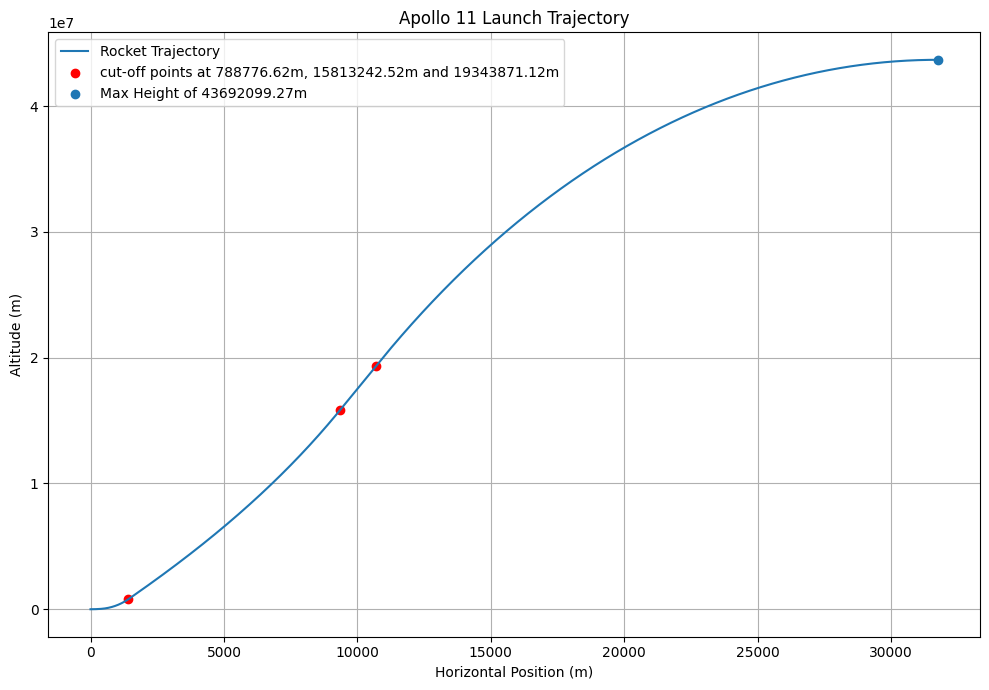

In [ ]:
#makes graphs big!
plt.figure(figsize=(10, 7))



#plots the trajectory of rocket and the points at which it drops its parts (depending on how many parts it drops)
plt.plot(x, altitude, label="Rocket Trajectory")
if len(alt_cut_off) > 2:
    plt.scatter(x_cut_off,alt_cut_off, c='red', label=f'cut-off points at {alt_cut_off[0]:.2f}m, {alt_cut_off[1]:.2f}m and {alt_cut_off[2]:.2f}m')
elif len(alt_cut_off) > 1:
    plt.scatter(x_cut_off,alt_cut_off, c='red', label=f'cut-off points at {alt_cut_off[0]:.2f}m, {alt_cut_off[1]:.2f}')
elif len(alt_cut_off) == 1:
    plt.scatter(x_cut_off,alt_cut_off, c='red', label=f'cut-off points at {alt_cut_off[0]:.2f}')

#shows the highest point in the rocket's trajectory
plt.scatter(x[altitude.index(max(altitude))], max(altitude),label=f"Max Height of {max(altitude):.2f}m")

#makes labels and titles
plt.xlabel("Horizontal Position (m)")
plt.ylabel("Altitude (m)")
plt.title("Apollo 11 Launch Trajectory")
plt.grid(True)
plt.legend()



#makes cool graph 😎
plt.tight_layout()
plt.show()

Figure 1: We graphed the trajectory of a rocket with 3 stages. Each red dot represents when the current stage ends, and after the third dot, the coasting phases begins until it reaches its maximum altitude.

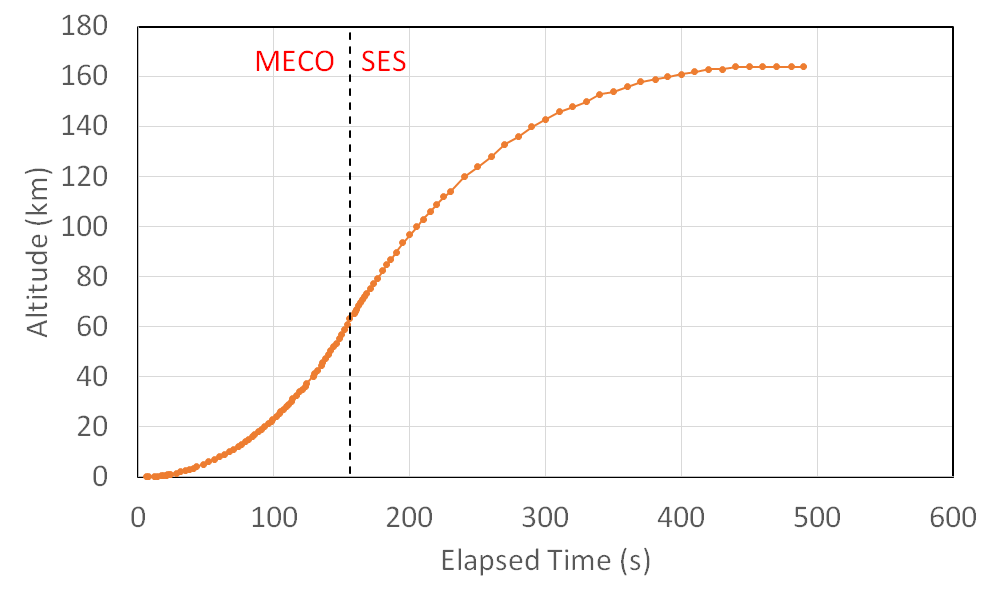

Figure 2: Above is a very similar representation of the graph we made from Michael De Podesta. It models the trajectory of a rocket, and it is very representative of our model.

###Then, we tested the speed of the rocket as it ascended into the atmosphere. In the ascending part of the simulation graph, the vertical speed vs horizontal distance matches very similarly to the graph we found online, from the NPL. This allows us to confirm the validity of our graph. Furthermore, we can make observe that the tangents of the position graph match the speeds of this graph. Knowing that speed is the derivative of position and speed is the norm of velocity, this allows us to fortify our argument.


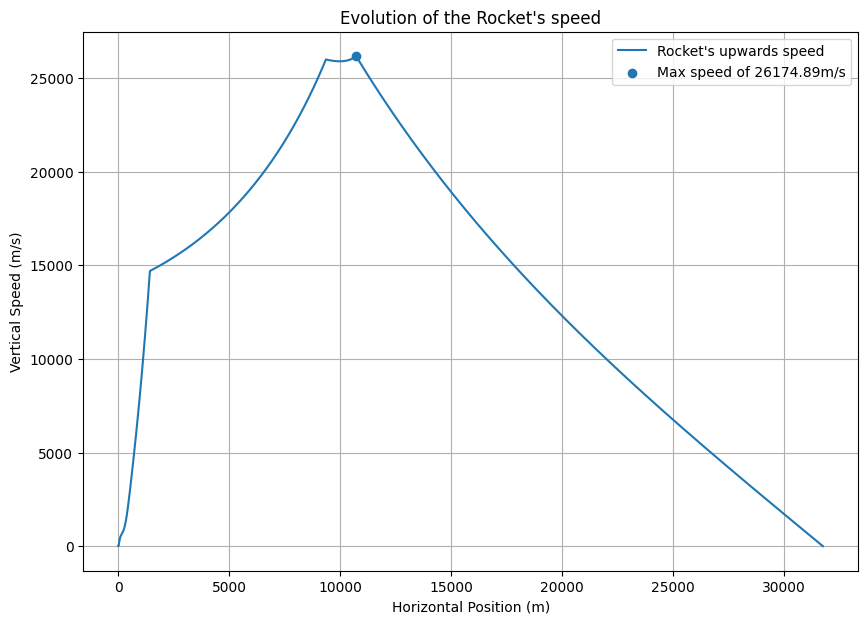

In [ ]:
#makes graphs big!
plt.figure(figsize=(10, 7))

#graphs the speed of the rocket in time
plt.plot(x, vy, label="Rocket's upwards speed")

#displays highest speed point and value of such speed
plt.scatter(x[vy.index(max(vy))], max(vy),label=f"Max speed of {max(vy):.2f}m/s")

#makes labels and titles
plt.xlabel("Horizontal Position (m)")
plt.ylabel("Vertical Speed (m/s)")
plt.title("Evolution of the Rocket's speed")
plt.legend()
plt.grid(True)


Figure 3: We can see the speed of the rocket evolving as it goes through its fuel. Initially, it uses up its fuel through each stage. After reaching its maximum speed, it moves into a coasting phase where it slowly decreases until 0 m/s

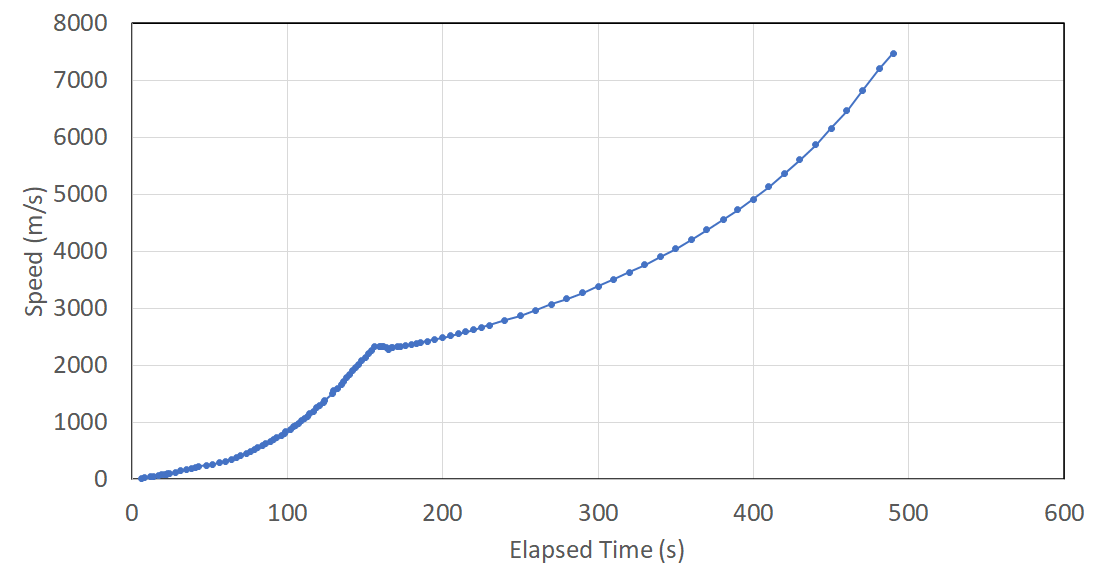

Figure 4: The rocket's speed increases until it runs out of fuel. Unlike ours, the coasting phase is not illustrated in this graph.

###Lastly,  the density we calculated and graphed in our code was accurate as we compared it to a graph from Research gate. Both graphs show a similar decrease in air density with the increase in altitude, allowing us to confirm the accuracy of our model. The visual correlation allowed us to confirm that our code correctly takes into account the changes of pressure and temperature to calculate the air density.


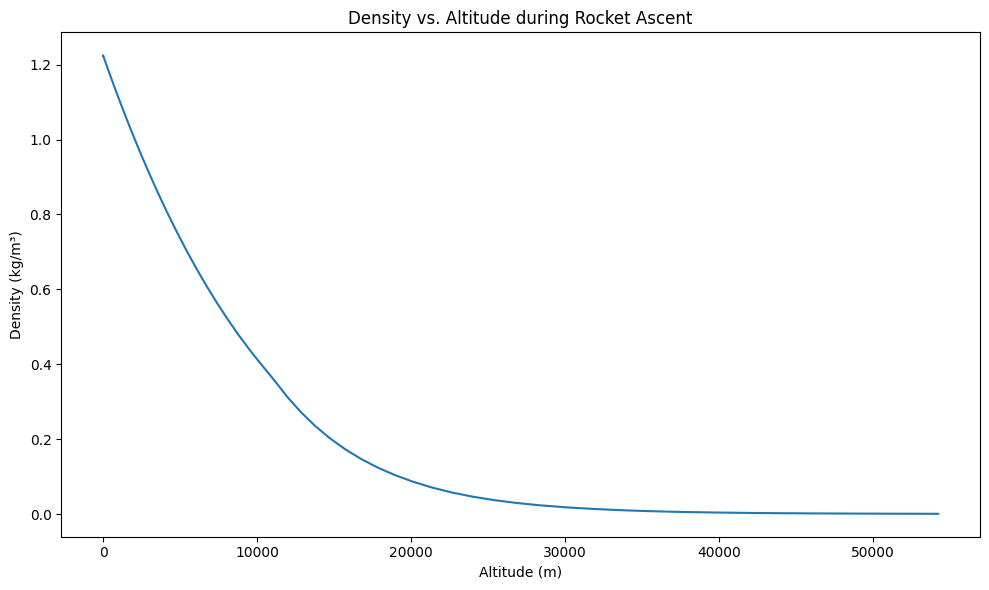

In [ ]:
#wowowow such cool libraries
import matplotlib.pyplot as plt
import numpy as np

#define constants
g = 9.8
M = 0.0289644

temperature = 20
drag_coeff = 0.5
atmosphere_layer = 0
pressure_layer = 101325
temperature_layer = 288.15
R = 8.314
lapse_layer = 0.0065
altitude_layer = 0
density_layer = 1.225

#define lists that will be used
altitude = []
time = []
a_density = [1.225]

#putting initial values of positions and speed
x = [0]
altitude = [0]

#vx is 10 as to make the trajectory not just go up and down directly
vx =[10]
vy = [0]
ay = [0]

#lists to make it look nicer on the graph
x_cut_off = []
alt_cut_off = []
vy_cut_off = []

#n_iterations = int(t_max/dt)
n_iterations= 200
dt = 1

#calculates density based on your layer and conditions
def calculate_density(altitude):

    if altitude < 11000:
        temp_layer = 288.15
        pressure_layer = 101325
        lapse = 0.0065

        temp = temp_layer - lapse * altitude
        pressure = pressure_layer * (temp / temp_layer) ** (g * M / (R * lapse))

    elif 11000 <= altitude < 20000:
        temp_layer = 216.65
        pressure_layer = 22632.1
        lapse = 0

        temp = temp_layer
        pressure = pressure_layer * np.exp(-g * M * (altitude - 11000) / (R * temp))

    elif 20000 <= altitude < 32000:
        temp_layer = 216.65
        pressure_layer = 5474.89
        lapse = -0.001

        temp = temp_layer - lapse * (altitude - 20000)
        pressure = pressure_layer * (temp / temp_layer) ** (g * M / (R * lapse))

    elif 32000 <= altitude < 47000:
        temp_layer = 228.65
        pressure_layer = 868.02
        lapse = -0.0028

        temp = temp_layer - lapse * (altitude - 32000)
        pressure = pressure_layer * (temp / temp_layer) ** (g * M / (R * lapse))

    elif 47000 <= altitude < 51000:
        temp_layer = 270.65
        pressure_layer = 110.91
        lapse = 0

        temp = temp_layer
        pressure = pressure_layer * np.exp(-g * M * (altitude - 47000) / (R * temp))

    elif 51000 <= altitude < 71000:
        temp_layer = 270.65
        pressure_layer = 66.94
        lapse = 0.0028

        temp = temp_layer - lapse * (altitude - 51000)
        pressure = pressure_layer * (temp / temp_layer) ** (g * M / (R * lapse))

    elif 71000 <= altitude < 84852:
        temp_layer = 214.65
        pressure_layer = 3.96
        lapse = 0.002

        temp = temp_layer - lapse * (altitude - 71000)
        pressure = pressure_layer * (temp / temp_layer) ** (g * M / (R * lapse))

    else: #Above 84.852 km

        temp = 186.87
        pressure = 0.3734

    density = pressure * M / (R * temp)
    a_density.append(density)
    return density


#calculates the force of the air drag felt by the rocket at a given speed, cross sectional aread and air density
def cal_air_drag(speed, cross_sectional_area, air_density):
    air_drag = 0.5 * air_density * speed**2 * drag_coeff * cross_sectional_area
    return air_drag

#determines gravitational force
def gravitational_force(mass):
    return mass*g


#Euler's method to update current position
def Eulers(i):
    x.append(x[i]+vx[i]*dt)
    altitude.append(altitude[i] + vy[i]*dt)
    vx.append(vx[i])
    vy.append(vy[i] + ay[i]*dt)

#launch function, including the three phases of the Saturn V rocket and a coast phase!
def launch(total_fuel):

    #updating information for first stage
    current_fuel1 = total_fuel*0.6
    thrust_force = 33850000
    mass = 189615.218 + current_fuel1
    cross_sectional_area = 317.31

    #initiating the step count to keep track (updated after finishing a loop!)
    time_step = 0

    #------first part of rocket------ cut-offs when fuel is depleted
    while current_fuel1 > 0 and time_step<50: #cutt-off early to make density variation visible

        #Euler's for position
        Eulers(time_step)

        #updating mass and fuel count
        burn_rate = 1285.6
        mass -= burn_rate
        current_fuel1 -= burn_rate

        #calculates density, drag force and grav force to associate them to a variable
        density = calculate_density(altitude[time_step+1])
        drag = cal_air_drag(vy[time_step+1], cross_sectional_area, density)
        grav = gravitational_force(mass)

        #calculates acceleration using F=ma
        negative_forces = drag + grav
        F = thrust_force - negative_forces

        #append new acceleration value
        a_y = F/mass
        ay.append(a_y)



        #keeps track of step count, adding one for the next loop
        time_step += 1

    #adding cut_off points to make visulization better
    x_cut_off.append(x[time_step])
    alt_cut_off.append(altitude[time_step])
    vy_cut_off.append(vy[time_step])

    #updating information for second stage
    current_fuel2 = total_fuel*0.3
    thrust_force = 2431000
    mass = 58980.616 + total_fuel*0.3
    cross_sectional_area = 137.44

    #------second part of rocket------ cut-offs when fuel is depleted
    while current_fuel2 > 0 and time_step<50: #cutt-off early to make density variation visible

        #Euler's for position
        Eulers(time_step)

        #updating mass and fuel count
        burn_rate = 113.53
        mass -= burn_rate
        current_fuel2 -= burn_rate

        #calculates density, drag force and grav force to associate them to a variable
        density = calculate_density(altitude[time_step+1])
        drag = cal_air_drag(vy[time_step+1], cross_sectional_area, density)
        grav = gravitational_force(mass)


        #calculates acceleration using F=ma
        negative_forces = drag + grav
        F = thrust_force - negative_forces


        #append new acceleration value
        a_y = F/mass
        ay.append(a_y)

        #keeps track of step count, adding one for the next loop
        time_step += 1

    #adding cut_off points to make visulization better
    x_cut_off.append(x[time_step])
    alt_cut_off.append(altitude[time_step])
    vy_cut_off.append(vy[time_step])

    #updating information for third stage
    current_fuel3 = total_fuel*0.1
    thrust_force = 486200
    mass = 16977.96 + current_fuel3
    cross_sectional_area = 137.4444

    #------third part of rocket------ makes sure to stop when speed is 0 to find highest altitude reacher
    while current_fuel3 > 0 and time_step<50: #cutt-off early to make density variation visible

        #Euler's for position
        Eulers(time_step)

        #updating mass and fuel count
        burn_rate = 220.9
        mass -= burn_rate
        current_fuel3 -= burn_rate

        #calculates density, drag force and grav force to associate them to a variable
        density = calculate_density(altitude[time_step+1])
        drag = cal_air_drag(vy[time_step+1], cross_sectional_area, density)
        grav = gravitational_force(mass)


        #calculates acceleration using F=ma
        negative_forces = drag + grav
        F = thrust_force - negative_forces


        #append new acceleration value
        a_y = F/mass
        ay.append(a_y)

        #keeps track of step count, adding one for the next loop
        time_step += 1

    #adding cut_off points to make visulization better
    x_cut_off.append(x[time_step])
    alt_cut_off.append(altitude[time_step])
    vy_cut_off.append(vy[time_step])
    thrust_force = 0

    #------coasting phase----
    while vy[time_step] >= 0 and time_step<50: #cutt-off early to make density variation visible

        #Euler's for position
        Eulers(time_step)


        #calculates density, drag force and grav force to associate them to a variable
        density = calculate_density(altitude[time_step+1])
        drag = cal_air_drag(vy[time_step+1], cross_sectional_area, density)
        grav = gravitational_force(mass)


        #calculates acceleration using F=ma
        negative_forces = drag + grav
        F = thrust_force - negative_forces


        #append new acceleration value
        a_y = F/mass
        ay.append(a_y)

        #print(f"vy = {vy[time_step+1]:.2f}")

        #keeps track of step count, adding one for the next loop
        time_step += 1


#simulating launch
launch(300_000)

#makes graph big!
plt.figure(figsize=(10, 6))

#makes a graph to show the evolution of density through the different altitudes

plt.plot(altitude, a_density)
plt.xlabel("Altitude (m)")
plt.ylabel("Density (kg/m³)")
plt.title("Density vs. Altitude during Rocket Ascent")


#makes cool graph 😎
plt.tight_layout()
plt.show()

Figure 5: The density decreases with altitude. It eventually becomes 0 as we approach altitudes where the amount of air particles decreases significantly.

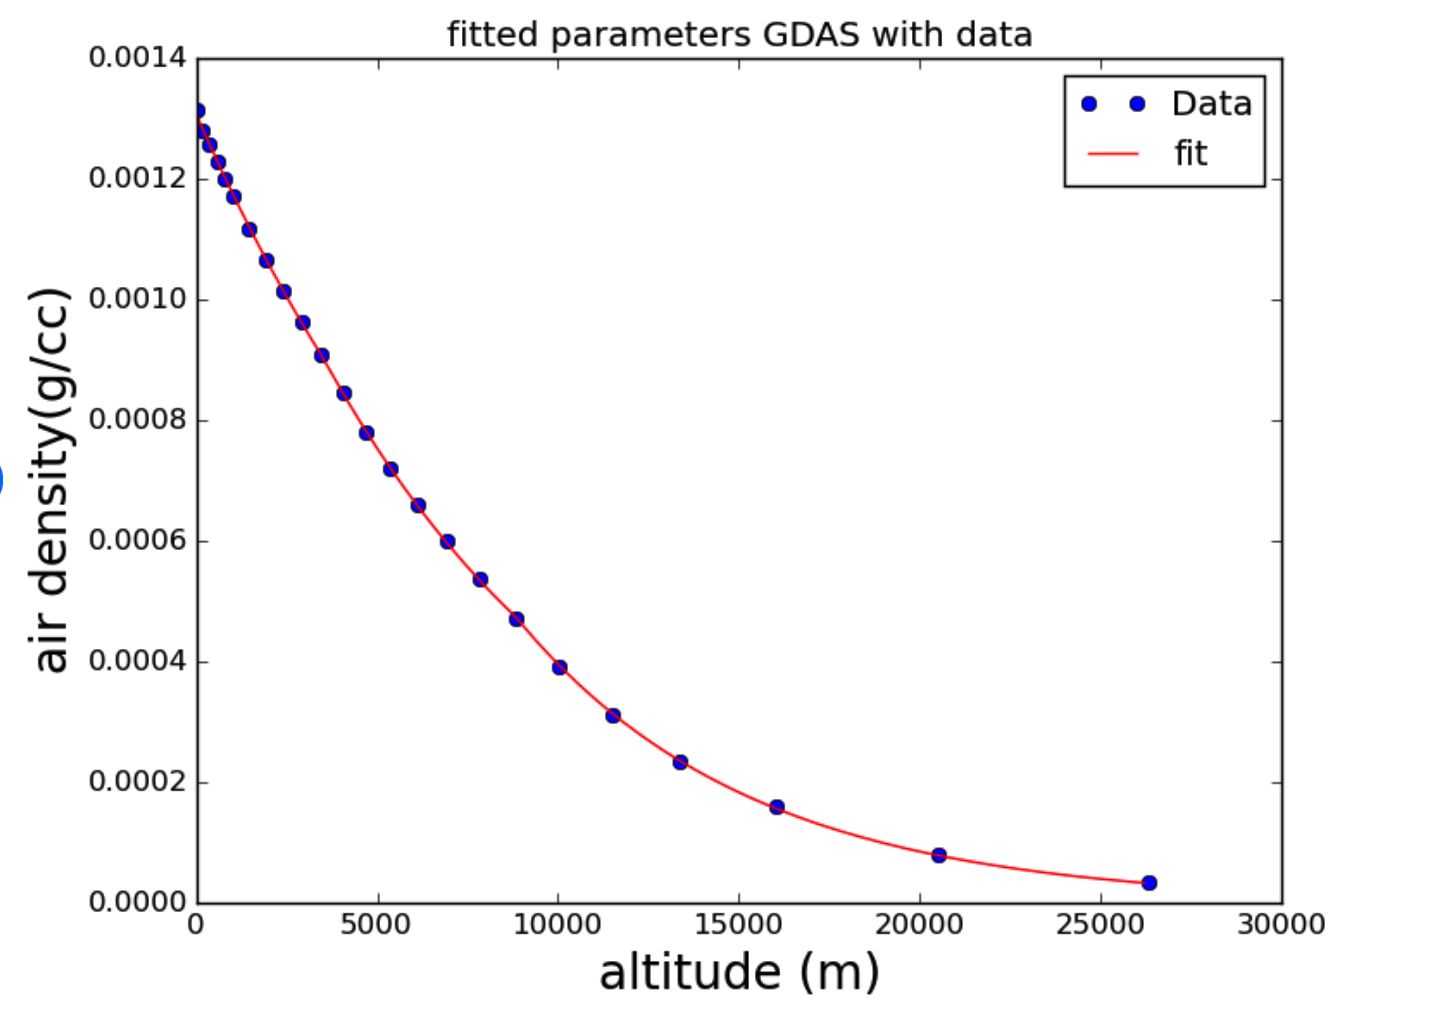

Figure 6: The air density decreases in a very similar manner. The units are in $g/cc$, however if we convert these numbers to $kg/m^3$, the graphs match very similarly and confirm our density graph

###For the internal verifications, we made sure the code was tracking the forces, positions, speeds, temperature changes and masses correctly with print statements. They allowed us to make changes to sections that needed those modifications. We calculated certain results by hand and compared to what the code gave out in order to understand which segments of the code wrongly outputted values as it ran through iterations. For example, as the code ran through the iterations, we tracked the fuel consumed and made sure it was depleting at the correct rate for the current stage the rocket is in. In addition, we also predicted the distance on the horizontal displacement at which each stage should drop. We added red dots on the graph when the stages change, in order to see if the stages drop at the correct distance when compared to our calculations.


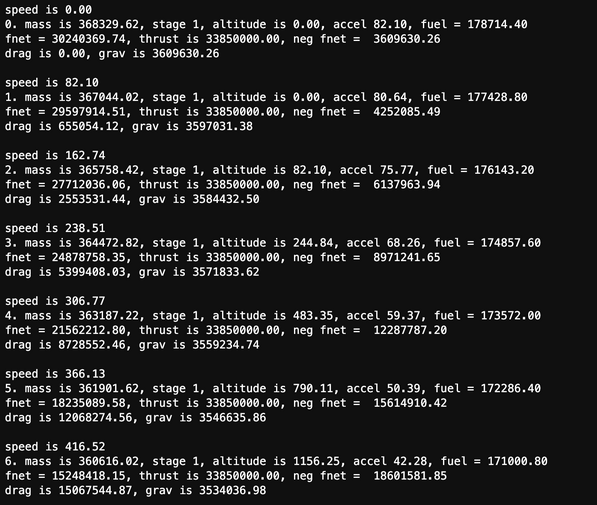

Figure 7: Results from the various print statements. Note that in our code, the DT is of 0.1s, but in this version of the code, it is of 1s to make sure the changes are visible.

#**Results & Discussion**
---

###The way we will be displaying our results is through our graphs. It will allow us to visualize the simulation of a rocket launch and understand its trajectory. The visual representation of the different speeds of the rocket at an altitude of 100 km allows us to understand how the total mass of fuel impacts the speed of the rocket at this height.

###Certain amounts of fuel do not allow for the rocket to get up to 100 km, but after we reach the minimum amount of fuel required to get to 100 km, the speed increases very rapidly. The slight dip in the initial moments of the increasing fuel simulation is due to the quick burn out of fuel as the rocket can’t maintain it’s thrust long enough during the specific stage as it combats the gravitational force and the drag force. Consequently, despite having less mass, it loses speed at the 100 km mark. Afterwards, the increasing fuel allows for the rocket to maintain its thrust for longer and have higher speeds at the threshold. For our rocket's condition, the optimal fuel needed to reach 100 km above sea level at the fastest speed possible is 116000 kg. Adding more fuel to the rocket, passing this amount, reduces the speed that the rocket has at the 100 km mark since the gravitational force increases while diminishing the net force, which affects the speed the rocket obtains at 100 km. After about 500000 kg of fuel, the rocket has too much extra mass to be able to reach the 100 km point. In consequence, the speeds can’t be detected past this point.

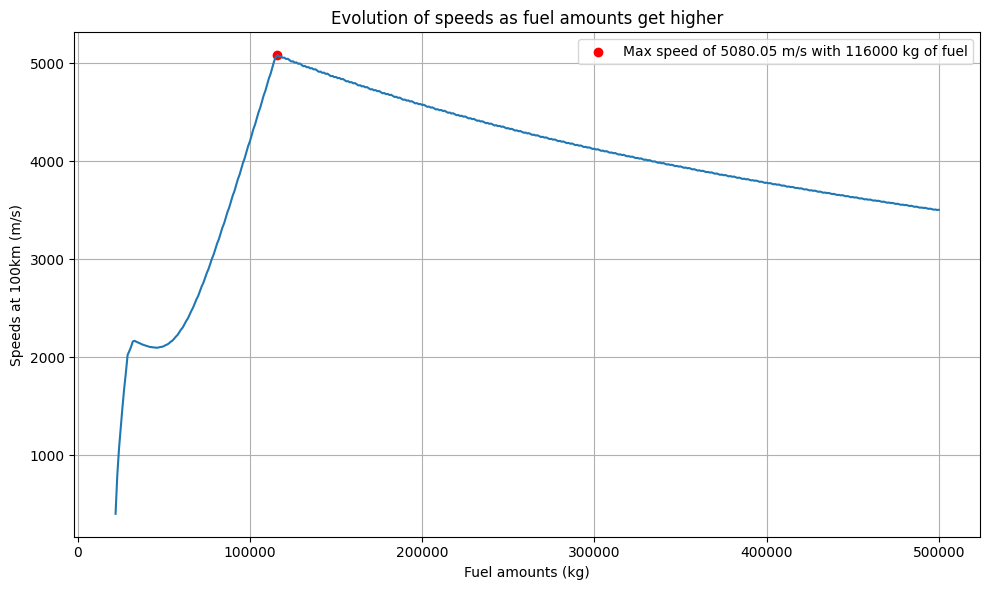

In [ ]:
#wowowow such cool libraries
import matplotlib.pyplot as plt
import numpy as np


#define constants
g = 9.8
M = 0.0289644


temperature = 20
drag_coeff = 0.5
atmosphere_layer = 0
pressure_layer = 101325
temperature_layer = 288.15
R = 8.314
lapse_layer = 0.0065
altitude_layer = 0
density_layer = 1.225


#define lists that will be used
altitude = []
time = []
a_density = [1.225]

dt = 0.1


#make dictionnary of final speeds and fuel for graphing purposes
fuel_speed = {}


#calculates density based on your layer and conditions
def calculate_density(altitude):

    if altitude < 11000:
        temp_layer = 288.15
        pressure_layer = 101325
        lapse = 0.0065


        temp = temp_layer - lapse * altitude
        pressure = pressure_layer * (temp / temp_layer) ** (g * M / (R * lapse))


    elif 11000 <= altitude < 20000:
        temp_layer = 216.65
        pressure_layer = 22632.1
        lapse = 0


        temp = temp_layer
        pressure = pressure_layer * np.exp(-g * M * (altitude - 11000) / (R * temp))


    elif 20000 <= altitude < 32000:
        temp_layer = 216.65
        pressure_layer = 5474.89
        lapse = -0.001


        temp = temp_layer - lapse * (altitude - 20000)
        pressure = pressure_layer * (temp / temp_layer) ** (g * M / (R * lapse))


    elif 32000 <= altitude < 47000:
        temp_layer = 228.65
        pressure_layer = 868.02
        lapse = -0.0028


        temp = temp_layer - lapse * (altitude - 32000)
        pressure = pressure_layer * (temp / temp_layer) ** (g * M / (R * lapse))


    elif 47000 <= altitude < 51000:
        temp_layer = 270.65
        pressure_layer = 110.91
        lapse = 0


        temp = temp_layer
        pressure = pressure_layer * np.exp(-g * M * (altitude - 47000) / (R * temp))


    elif 51000 <= altitude < 71000:
        temp_layer = 270.65
        pressure_layer = 66.94
        lapse = 0.0028


        temp = temp_layer - lapse * (altitude - 51000)
        pressure = pressure_layer * (temp / temp_layer) ** (g * M / (R * lapse))


    elif 71000 <= altitude < 84852:
        temp_layer = 214.65
        pressure_layer = 3.96
        lapse = 0.002


        temp = temp_layer - lapse * (altitude - 71000)
        pressure = pressure_layer * (temp / temp_layer) ** (g * M / (R * lapse))


    else: #Above 84.852 km

        temp = 186.87
        pressure = 0.3734


    density = pressure * M / (R * temp)
    a_density.append(density)
    return density


#calculates the force of the air drag felt by the rocket at a given speed, cross sectional aread and air density
def cal_air_drag(speed, cross_sectional_area, air_density):
    air_drag = 0.5 * air_density * speed**2 * drag_coeff * cross_sectional_area
    return air_drag


#determines gravitational force
def gravitational_force(mass):
    return mass*g


#Euler's method to update current position
def Eulers(i):
    x.append(x[i]+vx[i]*dt)
    altitude.append(altitude[i] + vy[i]*dt)
    vx.append(vx[i])
    vy.append(vy[i] + ay[i]*dt)


#launch function, including the three phases of the Saturn V rocket and a coast phase!
def launch(total_fuel):

    global x
    global altitude
    global vx
    global vy
    global ay


    #putting initial values of positions and speed
    x = [0]
    altitude = [0]


    #vx is 10 as to make the trajectory not just go up and down directly
    vx =[10]
    vy = [0]
    ay = [0]


    #updating information for first stage
    current_fuel1 = total_fuel*0.6
    thrust_force = 33850000
    mass = 189615.218 + current_fuel1
    cross_sectional_area = 317.31


    #initiating the step count to keep track (updated after finishing a loop!)
    time_step = 0


    #------first part of rocket------ cut-offs when fuel is depleted
    while current_fuel1 > 0:


        #Euler's for position
        Eulers(time_step)


        #updating mass and fuel count
        burn_rate = 1285.6*dt
        mass -= burn_rate
        current_fuel1 -= burn_rate


        #calculates density, drag force and grav force to associate them to a variable
        density = calculate_density(altitude[time_step+1])
        drag = cal_air_drag(vy[time_step+1], cross_sectional_area, density)
        grav = gravitational_force(mass)


        #see if rocket has passed atmosphere condition
        if altitude[time_step+1] >= 100000:
            fuel_speed[total_fuel] = vy[time_step+1]
            return

        #calculates acceleration using F=ma
        negative_forces = drag + grav
        F = thrust_force - negative_forces


        #append new acceleration value
        a_y = F/mass
        ay.append(a_y)


        #keeps track of step count, adding one for the next loop
        time_step += 1


    #updating information for second stage
    current_fuel2 = total_fuel*0.3
    thrust_force = 2431000
    mass = 58980.616 + current_fuel2
    cross_sectional_area = 137.44


    #------second part of rocket------ cut-offs when fuel is depleted
    while current_fuel2 > 0:


        #Euler's for position
        Eulers(time_step)


        #updating mass and fuel count
        burn_rate = 113.53*dt
        mass -= burn_rate
        current_fuel2 -= burn_rate


        #calculates density, drag force and grav force to associate them to a variable
        density = calculate_density(altitude[time_step+1])
        drag = cal_air_drag(vy[time_step+1], cross_sectional_area, density)
        grav = gravitational_force(mass)


        #see if rocket has passed atmosphere condition
        if altitude[time_step+1] >= 100000:
            fuel_speed[total_fuel] = vy[time_step+1]
            return


        #calculates acceleration using F=ma
        negative_forces = drag + grav
        F = thrust_force - negative_forces

        #append new acceleration value
        a_y = F/mass
        ay.append(a_y)

        #keeps track of step count, adding one for the next loop
        time_step += 1


    #updating information for third stage
    current_fuel3 = total_fuel*0.1
    thrust_force = 486200
    mass = 16977.96 + current_fuel3
    cross_sectional_area = 137.4444


    #------third part of rocket------ makes sure to stop when speed is 0 to find highest altitude reacher
    while current_fuel3 > 0:


        #Euler's for position
        Eulers(time_step)


        #updating mass and fuel count
        burn_rate = 220.9*dt
        mass -= burn_rate
        current_fuel3 -= burn_rate


        #calculates density, drag force and grav force to associate them to a variable for future, and easier use
        density = calculate_density(altitude[time_step+1])
        drag = cal_air_drag(vy[time_step+1], cross_sectional_area, density)
        grav = gravitational_force(mass)


        #see if rocket has passed atmosphere condition
        if altitude[time_step+1] >= 100000:
            fuel_speed[total_fuel] = vy[time_step+1]
            return


        #calculates acceleration using F=ma
        negative_forces = drag + grav
        F = thrust_force - negative_forces

        #append new acceleration value
        a_y = F/mass
        ay.append(a_y)

        #keeps track of step count, adding one for the next loop
        time_step += 1

    thrust_force = 0


    #------coasting phase----
    while vy[time_step] >= 0:


        #Euler's for position
        Eulers(time_step)

        #calculates density, drag force and grav force to associate them to a variable
        density = calculate_density(altitude[time_step+1])
        drag = cal_air_drag(vy[time_step+1], cross_sectional_area, density)
        grav = gravitational_force(mass)


        #see if rocket has passed atmosphere condition
        if altitude[time_step+1] >= 100000:
            fuel_speed[total_fuel] = vy[time_step+1]
            return


        #calculates acceleration using F=ma
        negative_forces = drag + grav
        F = thrust_force - negative_forces




        #append new acceleration value
        a_y = F/mass
        ay.append(a_y)


        #print(f"vy = {vy[time_step+1]:.2f}")

        #keeps track of step count, adding one for the next loop
        time_step += 1


#makes fuel intervals for varying fuel amounts
fuel_amounts = np.arange(0,500_001,1000)
fuel_amounts = list(fuel_amounts)


#simulates the rocket for different fuel amounts
for fuel_amount in fuel_amounts:

    #simulating launch for the iteration's fuel amount
    launch(fuel_amount)


#makes graph big!
plt.figure(figsize=(10, 6))


#plot speed vs starting fuel
plt.plot(fuel_speed.keys(), fuel_speed.values())

#Find the key-value pair with the highest speed
max_key = max(fuel_speed, key=fuel_speed.get)
max_speed = fuel_speed[max_key]

#Plot this point
plt.scatter([max_key], [max_speed], color="r", label=f"Max speed of {max_speed:.2f} m/s with {max_key} kg of fuel")

#makes labels and titles
plt.xlabel("Fuel amounts (kg)")
plt.ylabel("Speeds at 100km (m/s)")
plt.title("Evolution of speeds as fuel amounts get higher")
plt.grid(True)
plt.legend()


#makes cool graph 😎
plt.tight_layout()
plt.show()

Figure 8: The speed of the rocket at 100 km above sea level changes as the total fuel increases. After 116000 kg of fuel, the extra weight of fuel makes the rocket decline in its speed at the 100 km mark.

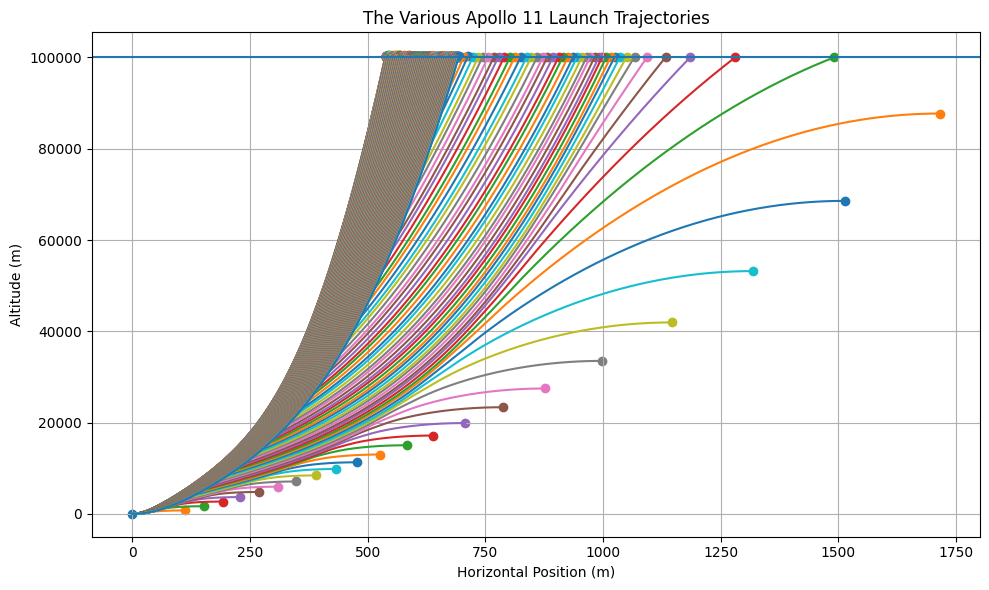

In [ ]:
#makes graph big!
plt.figure(figsize=(10, 6))

#simulates the rocket for different fuel amounts
for fuel_amount in fuel_amounts:

    #simulating launch for the iteration's fuel amount
    launch(fuel_amount)

    #plots the trajectory of rocket and the points at which it drops its parts (depending on how many parts it drops)
    plt.plot(x, altitude, label="Rocket Trajectory")

    #shows the highest point
    plt.scatter(x[altitude.index(max(altitude))], max(altitude),label=f"Max Height of {max(altitude):.2f}m")


#makes line at 100km line to show threshold
plt.axhline(100000,0,2000)

#makes labels and titles
plt.xlabel("Horizontal Position (m)")
plt.ylabel("Altitude (m)")
plt.title("The Various Apollo 11 Launch Trajectories")
plt.grid(True)



#makes cool graph 😎
plt.tight_layout()
plt.show()

Figure 9: We can see all the different trajectories of the rockets with different amounts of fuel. Some achieve the 100 km mark as they have enough fuel to power to them while some do not achieve this as they either have too much fuel or not enough fuel.

###Moreover, the trajectory of the rockets with different fuel amounts is also impacted. The rockets with the lower fuel amounts are not able to reach the 100 km mark as they don't have enough fuel to sustain their flight towards this altitude. Lower fuel amounts mean that they must enter the coasting phase quicker, thus having no chance to reach the 100km threshold. As fuel amount is increased, more thrust can be extracted from the fuel, enabling the rockets to reach the required altitude in their coasting phase. The more fuel that is added, the earlier they reach the required height, up until a certain point where extra fuel weighs the rocket down more than the thrust produced by it.

###The assumptions that the thrust, fuel consumption, gravitational acceleration are constant, and the generalized drag coefficient are limitations of our rocket model. In fact, the thrust of a rocket varies based on the ambient pressure, exhaust pressure, exhaust velocity of the ejected gas, area of the engine's exhaust and the mass flow inside the engine. We were not able to find accurate and consistent values for these conditions, thus impacting our model, as we had to assume that it is constant throughout each stage. This impacts the trajectory of the rocket, since thrust would slowly get higher as the ambient pressure gets lower. In addition, fuel also burns at a varying rate but due to the complexity of the calculations, we neglected this aspect and assumed it to be constant. Moreover, the gravitational acceleration of Earth was assumed to be constant in each layer of the atmosphere, due, in part, to its slight variation from sea level to 100 km above. Lastly, the drag coefficient of the rocket was generalized to the one of a cone due to the similarities in their general shape. In reality, the shape of a rocket and the shape of a cone differ so the coefficient differs as well. However, we did not manage to find the actual coefficient of the Saturn V rocket.

###In order to expand on this, we can try to incorporate a model that takes into account all the assumptions we made to be constant. We can have a model taking into account the varying thrusts at the different layers in the atmosphere as it depletes through its fuel. We can incorporate the varying fuel burning rates as well as take into account the actual drag coefficient of the Saturn V rocket. We could also consider the varying gravitational acceleration as altitude increases. Many variables that we considered to be constant could be taken as non-constants, as this would increase the accuracy of the code.


#**Conclusion**
---

###In conclusion, our code simulates the launch of a rocket while observing the speeds at a 100 km above the sea level as total fuel increases. To answer our original question, we found that as total fuel increases, the speed of the rocket increases rapidly for the initial fuel amounts and drops slightly afterwards as it can’t maintain its thrust long enough during the specific stage it is in. Then, the speed increases up to its peak at around 116000 kg of total fuel before going back down slowly as gravity takes over and overpowers the thrust. In order to accomplish this, we used Euler’s method to keep track of the position of the rocket. Our code then uses constant fuel burning rates, constant thrusts, a generalized drag coefficient and a constant gravitational acceleration to calculate the acceleration of the rocket in the y-direction. The varying speeds are then stored and graphed to make a visual representations as seen above.


##References
de Podesta, M. (2021, January 14). Rocket science. Protons for Breakfast. https://protonsforbreakfast.wordpress.com/2021/01/14/rocket-science/
<br>
<br>
McDonnell Douglas Astronautics Company. (1968, December). Saturn S-IVB-205 flight evaluation stage report (SM-46990). National Aeronautics and Space Administration. https://www.nasa.gov/wp-content/uploads/static/history/afj/ap07fj/pdf/a07-s-ivb-flight-eval-rep-19700076411.pdfNASA+1NASA+1
<br>
<br>
Wikipedia contributors. (n.d.). International Standard Atmosphere. Wikipedia. Retrieved May 23, 2025, from https://en.wikipedia.org/wiki/International_Standard_Atmosphere
<br>
<br>
Wikipedia contributors. (n.d.). Barometric formula. Wikipedia. Retrieved May 23, 2025, from https://en.wikipedia.org/wiki/Barometric_formula
<br>
<br>
New Space Economy. (2024, August 15). Titans of the space race: Comparing the legendary Saturn V and revolutionary SpaceX Starship. https://newspaceeconomy.ca/2024/08/15/titans-of-the-space-race-comparing-the-legendary-saturn-v-and-revolutionary-spacex-starship/
<br>
<br>
J.F. Brière, J. Choquette. 2025. 360-420-DW W25-1-Intro to Programming. [accessed April 2025] https://docs.google.com/presentation/d/1mWh4UKVfHZ0iN8a6H5LE9QY7NpM8yffLmLGmLriIxfg/edit#slide=id.g1dd58c501b5_0_54
<br>
<br>
Mitra, P., Corstanje, A., Bonardi, A., Stijn Buitink, & Winchen, T. (2017). The effect of the atmospheric refractive index on the radio signal of extensive air showers using Global Data Assimilation System (GDAS). 35th International Cosmic Ray Conference, 325.
https://www.researchgate.net/publication/326810955_The_effect_of_the_atmospheric_refractive_index_on_the_radio_signal_of_extensive_air_showers_using_Global_Data_Assimilation_System_GDAS

## Final code!
It's pretty long :P (it's the same as in the results section, but you said you wanted it to be shown seperately so here you go!)

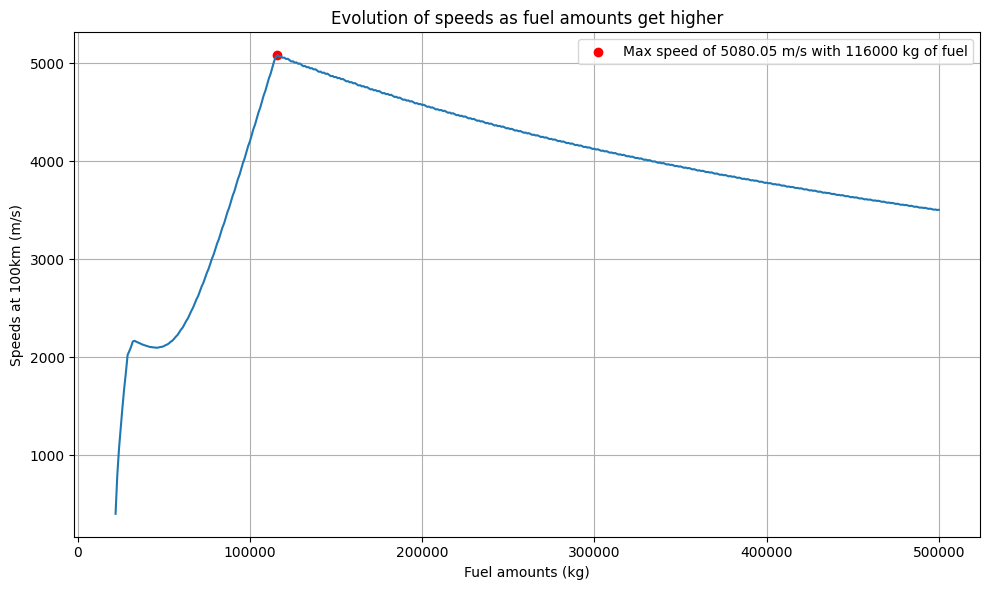

In [ ]:
#wowowow such cool libraries
import matplotlib.pyplot as plt
import numpy as np


#define constants
g = 9.8
M = 0.0289644


temperature = 20
drag_coeff = 0.5
atmosphere_layer = 0
pressure_layer = 101325
temperature_layer = 288.15
R = 8.314
lapse_layer = 0.0065
altitude_layer = 0
density_layer = 1.225


#define lists that will be used
altitude = []
time = []
a_density = [1.225]

dt = 0.1


#make dictionnary of final speeds and fuel for graphing purposes
fuel_speed = {}


#calculates density based on your layer and conditions
def calculate_density(altitude):

    if altitude < 11000:
        temp_layer = 288.15
        pressure_layer = 101325
        lapse = 0.0065


        temp = temp_layer - lapse * altitude
        pressure = pressure_layer * (temp / temp_layer) ** (g * M / (R * lapse))


    elif 11000 <= altitude < 20000:
        temp_layer = 216.65
        pressure_layer = 22632.1
        lapse = 0


        temp = temp_layer
        pressure = pressure_layer * np.exp(-g * M * (altitude - 11000) / (R * temp))


    elif 20000 <= altitude < 32000:
        temp_layer = 216.65
        pressure_layer = 5474.89
        lapse = -0.001


        temp = temp_layer - lapse * (altitude - 20000)
        pressure = pressure_layer * (temp / temp_layer) ** (g * M / (R * lapse))


    elif 32000 <= altitude < 47000:
        temp_layer = 228.65
        pressure_layer = 868.02
        lapse = -0.0028


        temp = temp_layer - lapse * (altitude - 32000)
        pressure = pressure_layer * (temp / temp_layer) ** (g * M / (R * lapse))


    elif 47000 <= altitude < 51000:
        temp_layer = 270.65
        pressure_layer = 110.91
        lapse = 0


        temp = temp_layer
        pressure = pressure_layer * np.exp(-g * M * (altitude - 47000) / (R * temp))


    elif 51000 <= altitude < 71000:
        temp_layer = 270.65
        pressure_layer = 66.94
        lapse = 0.0028


        temp = temp_layer - lapse * (altitude - 51000)
        pressure = pressure_layer * (temp / temp_layer) ** (g * M / (R * lapse))


    elif 71000 <= altitude < 84852:
        temp_layer = 214.65
        pressure_layer = 3.96
        lapse = 0.002


        temp = temp_layer - lapse * (altitude - 71000)
        pressure = pressure_layer * (temp / temp_layer) ** (g * M / (R * lapse))


    else: #Above 84.852 km

        temp = 186.87
        pressure = 0.3734


    density = pressure * M / (R * temp)
    a_density.append(density)
    return density




#calculates the force of the air drag felt by the rocket at a given speed, cross sectional aread and air density
def cal_air_drag(speed, cross_sectional_area, air_density):
    air_drag = 0.5 * air_density * speed**2 * drag_coeff * cross_sectional_area
    return air_drag


#determines gravitational force
def gravitational_force(mass):
    return mass*g


#Euler's method to update current position
def Eulers(i):
    x.append(x[i]+vx[i]*dt)
    altitude.append(altitude[i] + vy[i]*dt)
    vx.append(vx[i])
    vy.append(vy[i] + ay[i]*dt)


#launch function, including the three phases of the Saturn V rocket and a coast phase!
def launch(total_fuel):

    global x
    global altitude
    global vx
    global vy
    global ay


    #putting initial values of positions and speed
    x = [0]
    altitude = [0]


    #vx is 10 as to make the trajectory not just go up and down directly
    vx =[10]
    vy = [0]
    ay = [0]



    #updating information for first stage
    current_fuel1 = total_fuel*0.6
    thrust_force = 33850000
    mass = 189615.218 + current_fuel1
    cross_sectional_area = 317.31


    #initiating the step count to keep track (updated after finishing a loop!)
    time_step = 0


    #------first part of rocket------ cut-offs when fuel is depleted
    while current_fuel1 > 0:


        #Euler's for position
        Eulers(time_step)


        #updating mass and fuel count
        burn_rate = 1285.6*dt
        mass -= burn_rate
        current_fuel1 -= burn_rate


        #calculates density, drag force and grav force to associate them to a variable
        density = calculate_density(altitude[time_step+1])
        drag = cal_air_drag(vy[time_step+1], cross_sectional_area, density)
        grav = gravitational_force(mass)


        #see if rocket has passed atmosphere condition
        if altitude[time_step+1] >= 100000:
            fuel_speed[total_fuel] = vy[time_step+1]
            return

        #calculates acceleration using F=ma
        negative_forces = drag + grav
        F = thrust_force - negative_forces


        #append new acceleration value
        a_y = F/mass
        ay.append(a_y)


        #keeps track of step count, adding one for the next loop
        time_step += 1


    #updating information for second stage
    current_fuel2 = total_fuel*0.3
    thrust_force = 2431000
    mass = 58980.616 + current_fuel2
    cross_sectional_area = 137.44


    #------second part of rocket------ cut-offs when fuel is depleted
    while current_fuel2 > 0:


        #Euler's for position
        Eulers(time_step)


        #updating mass and fuel count
        burn_rate = 113.53*dt
        mass -= burn_rate
        current_fuel2 -= burn_rate


        #calculates density, drag force and grav force to associate them to a variable
        density = calculate_density(altitude[time_step+1])
        drag = cal_air_drag(vy[time_step+1], cross_sectional_area, density)
        grav = gravitational_force(mass)


        #see if rocket has passed atmosphere condition
        if altitude[time_step+1] >= 100000:
            fuel_speed[total_fuel] = vy[time_step+1]
            return


        #calculates acceleration using F=ma
        negative_forces = drag + grav
        F = thrust_force - negative_forces

        #append new acceleration value
        a_y = F/mass
        ay.append(a_y)

        #keeps track of step count, adding one for the next loop
        time_step += 1


    #updating information for third stage
    current_fuel3 = total_fuel*0.1
    thrust_force = 486200
    mass = 16977.96 + current_fuel3
    cross_sectional_area = 137.4444


    #------third part of rocket------ makes sure to stop when speed is 0 to find highest altitude reacher
    while current_fuel3 > 0:


        #Euler's for position
        Eulers(time_step)


        #updating mass and fuel count
        burn_rate = 220.9*dt
        mass -= burn_rate
        current_fuel3 -= burn_rate


        #calculates density, drag force and grav force to associate them to a variable for future, and easier use
        density = calculate_density(altitude[time_step+1])
        drag = cal_air_drag(vy[time_step+1], cross_sectional_area, density)
        grav = gravitational_force(mass)


        #see if rocket has passed atmosphere condition
        if altitude[time_step+1] >= 100000:
            fuel_speed[total_fuel] = vy[time_step+1]
            return


        #calculates acceleration using F=ma
        negative_forces = drag + grav
        F = thrust_force - negative_forces




        #append new acceleration value
        a_y = F/mass
        ay.append(a_y)

        #keeps track of step count, adding one for the next loop
        time_step += 1

    thrust_force = 0


    #------coasting phase----
    while vy[time_step] >= 0:


        #Euler's for position
        Eulers(time_step)

        #calculates density, drag force and grav force to associate them to a variable
        density = calculate_density(altitude[time_step+1])
        drag = cal_air_drag(vy[time_step+1], cross_sectional_area, density)
        grav = gravitational_force(mass)


        #see if rocket has passed atmosphere condition
        if altitude[time_step+1] >= 100000:
            fuel_speed[total_fuel] = vy[time_step+1]
            return


        #calculates acceleration using F=ma
        negative_forces = drag + grav
        F = thrust_force - negative_forces




        #append new acceleration value
        a_y = F/mass
        ay.append(a_y)


        #print(f"vy = {vy[time_step+1]:.2f}")

        #keeps track of step count, adding one for the next loop
        time_step += 1


#makes fuel intervals for varying fuel amounts
fuel_amounts = np.arange(0,500_001,1000)
fuel_amounts = list(fuel_amounts)


#simulates the rocket for different fuel amounts
for fuel_amount in fuel_amounts:

    #simulating launch for the iteration's fuel amount
    launch(fuel_amount)


#makes graph big!
plt.figure(figsize=(10, 6))


#plot speed vs starting fuel
plt.plot(fuel_speed.keys(), fuel_speed.values())

#Find the key-value pair with the highest speed
max_key = max(fuel_speed, key=fuel_speed.get)
max_speed = fuel_speed[max_key]

#Plot this point
plt.scatter([max_key], [max_speed], color="r", label=f"Max speed of {max_speed:.2f} m/s with {max_key} kg of fuel")

#makes labels and titles
plt.xlabel("Fuel amounts (kg)")
plt.ylabel("Speeds at 100km (m/s)")
plt.title("Evolution of speeds as fuel amounts get higher")
plt.grid(True)
plt.legend()


#makes cool graph 😎
plt.tight_layout()
plt.show()